<a href="https://colab.research.google.com/github/v2rinku/forqiskitalgo/blob/main/innerproduct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Inner Products


### *Part of the OIC Initiative: Qiskit Ready-to-Run Notebooks for Quantum Badge Enablement*

**Contributor Information**
* **Name:** Rinku Kanwar
* **Email:** v2rinku@us.ibm.com
* **GitHub ID:** v2rinku

**Notebook Details**
* **Badge:** Basics of Quantum Information
* **Lesson:** Quantum Circuits
* **Sub-Topic:** Inner products and projections

## Description

This notebook demonstrates the Inner Product between two quantum states.

The inner product of two vectors  is a scalar value calculated by summing the products of their corresponding components. It measures vector similarity, with a result of 0 indicating orthogonal (perpendicular) vectors.

The inner product between two quantum states represents the overlap or projection of one state onto another. It signifies how much of state is contained in the second state.


##  Setup & Environment
Ensure you have the necessary libraries installed. If running locally, ensure your virtual environment is active.

In [ ]:
# Install necessary packages if not already present
%pip install qiskit qiskit-aer matplotlib pylatexenc -q


In [51]:
import qiskit
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.1


##  1. Inner Product Calculation
Inner products are a way to compare two quantum states. *italicized text* When you take the inner product of two quantum states, you are essentially asking, "How similar are these two states?" The result will tell you whether the states are the same, completely different, or somewhere in between. If the result is a large number, the states are similar; if it's small or zero, they are very different or orthogonal.

In [82]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Define two quantum circuits representing the states |ψ⟩ and |ϕ⟩
qc_psi = QuantumCircuit(2)
qc_phi = QuantumCircuit(2)

# Example states |ψ⟩ = (1/√2)(|0⟩ + |1⟩) and |ϕ⟩ = (1/√2)(|0⟩ + i|1⟩)
qc_psi.h(0)
qc_psi.h(1)

qc_phi.h(0)
qc_phi.rx(np.pi/2, 1)


# Save statevectors for later use
qc_psi.save_statevector()
qc_phi.save_statevector()

opt_level = 2
sim = AerSimulator(method='statevector')

pm = generate_preset_pass_manager(optimization_level=opt_level, backend=sim)

qc_psi_compiled = pm.run(qc_psi)
qc_phi_compiled = pm.run(qc_phi)


job_psi = sim.run(qc_psi_compiled)
job_phi = sim.run(qc_phi_compiled)


# Get statevectors
statevector_psi = job_psi.result().get_statevector()
statevector_phi = job_phi.result().get_statevector()

 **The 2-qubit transpiled depth should be kept below ~30 to avoid excessive errors; single-qubit gates are ignored as they have lower error rates**.
 **The 2-qubit depth is checked after transpilation to ensure the circuit is optimized and not overly complex**.

In [90]:
# Decompose the circuit and check the 2-qubit depth
# This counts the depth of gates that act on 2 qubits only
depth_2qubit_psi = qc_psi_compiled.decompose().depth(lambda instr: len(instr.qubits) > 1)
depth_2qubit_phi = qc_phi_compiled.decompose().depth(lambda instr: len(instr.qubits) > 1)

# Output the 2-qubit gate depths for both circuits
print(f"2-qubit gate depth for |ψ⟩: {depth_2qubit_psi}")
print(f"2-qubit gate depth for |ϕ⟩: {depth_2qubit_phi}")

2-qubit gate depth for |ψ⟩: 1
2-qubit gate depth for |ϕ⟩: 1


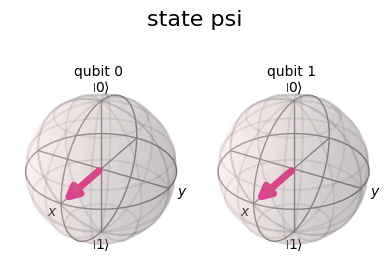

In [83]:
from qiskit.visualization import plot_bloch_multivector
plot_bloch_multivector(statevector_psi,title="state psi",figsize=(2,2))


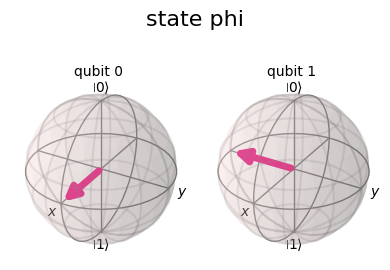

In [84]:
plot_bloch_multivector(statevector_phi,title="state phi",figsize=(2,2))

In [85]:



# Convert to Statevector objects for convenience
sv_psi = Statevector(statevector_psi)
sv_phi = Statevector(statevector_phi)
print('sv_psi:',sv_psi)
print('sv_phi:',sv_phi)

# Calculate inner product ⟨ψ|ϕ⟩
inner_product = np.vdot(statevector_psi, statevector_phi)
print(f"Inner product ⟨ψ|ϕ⟩: {inner_product}")

sv_psi: Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))
sv_phi: Statevector([0.5+0.j , 0.5+0.j , 0. -0.5j, 0. -0.5j],
            dims=(2, 2))
Inner product ⟨ψ|ϕ⟩: (0.5000000000000001-0.4999999999999999j)


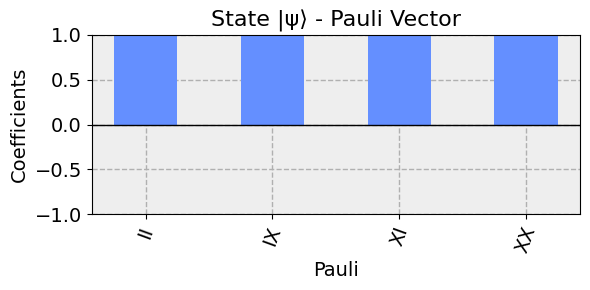

In [86]:
import matplotlib.pyplot as plt
from qiskit.visualization import plot_state_paulivec

plot_state_paulivec(sv_psi, title="State |ψ⟩ - Pauli Vector", figsize=(6,3))


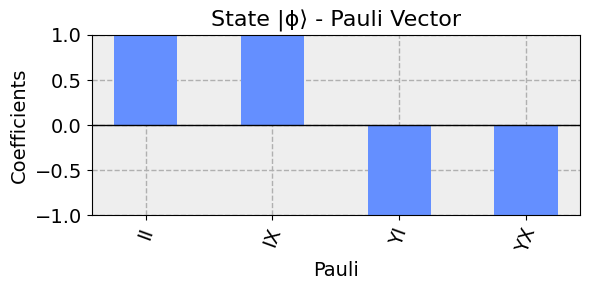

In [87]:
plot_state_paulivec(sv_phi, title="State |ϕ⟩ - Pauli Vector", figsize=(6,3))


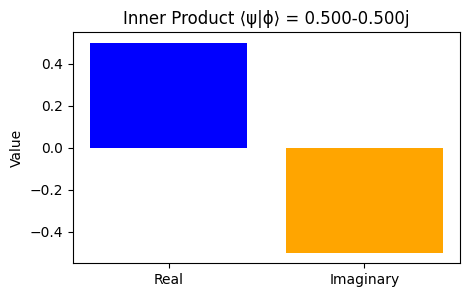

In [88]:
import matplotlib.pyplot as plt
from qiskit.visualization import plot_state_city
import numpy as np


real_part = np.real(inner_product)
imag_part = np.imag(inner_product)

plt.figure(figsize=(5, 3))
plt.bar(["Real", "Imaginary"], [real_part, imag_part], color=['blue', 'orange'])
plt.title(f"Inner Product ⟨ψ|ϕ⟩ = {inner_product:.3f}")
plt.ylabel("Value")
plt.show()

## 1.1 Relationship to the Euclidean norm

The inner product of a quantum state with itself gives you a measure of the "length" or "size" of that state. It's like measuring how big a vector is in space. This is related to something called the norm, which tells you how "strong" or "intense" the quantum state is. When a quantum state is measured, its norm is always a non-negative number, and if its norm is zero, the state doesn't exist (it’s a zero state).


In [6]:
# Euclidean norm of |ψ⟩ using ⟨ψ|ψ⟩
norm_psi = np.vdot(statevector_psi, statevector_psi)
print(f"Norm of |ψ⟩: {np.sqrt(norm_psi)}")

# Euclidean norm of |ϕ⟩ using ⟨ϕ|ϕ⟩
norm_phi = np.vdot(statevector_phi, statevector_phi)
print(f"Norm of |ϕ⟩: {np.sqrt(norm_phi)}")

Norm of |ψ⟩: (1+0j)
Norm of |ϕ⟩: (1+0j)


## 1.2 Conjugate Symmetry

The concept of conjugate symmetry tells us that the inner product of two states, say ψ and ϕ, behaves in a special way when you switch their order. Essentially, if you swap the two states in the inner product, the result is the complex conjugate of the original value. It’s like saying if you swap two people in a team, the result of their work gets "flipped" in some way, but still related. This property is important for dealing with complex numbers in quantum mechanics.

In [52]:
# Conjugate symmetry: ⟨ψ|ϕ⟩ == (⟨ϕ|ψ⟩)*

inner_product_conjugate = np.conj(np.vdot(statevector_phi, statevector_psi))
print(f"Conjugate symmetry check ⟨ψ|ϕ⟩ = (⟨ϕ|ψ⟩)*: {inner_product_conjugate}")

Conjugate symmetry check ⟨ψ|ϕ⟩ = (⟨ϕ|ψ⟩)*: (0.5000000000000001-0.4999999999999999j)


### 1.3 Linearity in the Second Argument (and Conjugate Linearity in the First)

The inner product behaves in a predictable way when we add quantum states or multiply them by a number. For example, if you have two quantum states, ϕ1 and ϕ2, and you combine them (by adding them together or multiplying by a constant), the inner product with another state ψ follows the same pattern. It’s like saying if you mix two ingredients in a recipe, the outcome depends on how much of each ingredient you use. Similarly, the inner product is predictable and consistent when you combine or scale the states.

In [8]:
# Suppose α1 = 1, α2 = -1 for linear combination of |ϕ1⟩ and |ϕ2⟩
alpha1 = 1
alpha2 = -1

# Define two new quantum states |ϕ1⟩ and |ϕ2⟩
qc_phi1 = QuantumCircuit(2)
qc_phi2 = QuantumCircuit(2)

# |ϕ1⟩ = (1/√2)(|0⟩ + |1⟩), |ϕ2⟩ = (1/√2)(|0⟩ + i|1⟩)
qc_phi1.h(0)
qc_phi1.h(1)

qc_phi2.h(0)
qc_phi2.rx(np.pi/2, 1)

# Save statevectors for later use
qc_phi1.save_statevector()
qc_phi2.save_statevector()

# Build simulator and transpile
qc_phi1_compiled = transpile(qc_phi1, sim)
qc_phi2_compiled = transpile(qc_phi2, sim)

# Run and get results
job_phi1 = sim.run(qc_phi1_compiled)
job_phi2 = sim.run(qc_phi2_compiled)

# Get statevectors
statevector_phi1 = job_phi1.result().get_statevector()
statevector_phi2 = job_phi2.result().get_statevector()

# Linearity in the second argument: ⟨ψ|α1|ϕ1⟩ + α2⟨ψ|ϕ2⟩
inner_product_linear = alpha1 * np.vdot(statevector_psi, statevector_phi1) + alpha2 * np.vdot(statevector_psi, statevector_phi2)
print(f"Linearity in the second argument: ⟨ψ|α1|ϕ1⟩ + α2⟨ψ|ϕ2⟩ = {inner_product_linear}")

Linearity in the second argument: ⟨ψ|α1|ϕ1⟩ + α2⟨ψ|ϕ2⟩ = (0.4999999999999999+0.4999999999999999j)


### 1.4 The Cauchy–Schwarz Inequality

The Cauchy–Schwarz inequality is a rule that tells you that the inner product of two quantum states is always smaller or equal to the product of their "sizes." It’s like saying that if you’re comparing two things, the "overlap" (inner product) can’t be bigger than the size of both things put together. This rule is super important because it helps us avoid unrealistic situations in quantum mechanics and ensures that certain relationships between states stay within limits.

In [9]:
# Cauchy–Schwarz inequality: |⟨ψ|ϕ⟩| <= ||ψ|| * ||ϕ||

cauchy_schwarz_check = np.abs(inner_product) <= np.sqrt(norm_psi) * np.sqrt(norm_phi)
print(f"Cauchy-Schwarz inequality check: |⟨ψ|ϕ⟩| <= ||ψ|| * ||ϕ||: {cauchy_schwarz_check}")

Cauchy-Schwarz inequality check: |⟨ψ|ϕ⟩| <= ||ψ|| * ||ϕ||: True


<div style="background:#f0f0f0 !important; padding:10px;">
<h3>About the Project</h3>
<p>
This notebook is part of a OIC initiative to provide standardized, badge-aligned Qiskit implementations for the IBM Quantum Learning curriculum.
These notebooks are designed to be ready-to-run, reusable, and scalable for quantum enthusiasts.
</p>
<p>
<i>"Translating Quantum Theory into Action, one qubit at a time."</i>
</p>
<p><small>
© IBM Corp., 2026
</small>
</p>
</div>